# Student Placement Eligibility Prediction using Logistic Regression

## Project Overview

This project predicts whether a student is likely to meet a placement eligibility criterion using Logistic Regression.

The model uses academic and placement-related features such as CGPA, attendance percentage, coding score, projects completed, internship experience, and backlogs.

## 1. Import Libraries

In [1]:
import pandas as pd

df = pd.read_csv("dataset_07_student_placement_eligibility.csv")

print(df.head())
print(df.shape)

   cgpa  attendance_pct  coding_score  projects_completed  internship_months  \
0  8.18           76.43             4                   3                 14   
1  9.28           46.50             3                   3                 50   
2  7.61           30.59             6                   2                 25   
3  7.47           50.98             0                   4                 56   
4  6.17           25.42             2                   2                 55   

   backlogs  target  
0         4       1  
1         5       0  
2         2       1  
3         3       0  
4         4       1  
(1000, 7)


## 2. Load and Explore Dataset

In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cgpa                1000 non-null   float64
 1   attendance_pct      1000 non-null   float64
 2   coding_score        1000 non-null   int64  
 3   projects_completed  1000 non-null   int64  
 4   internship_months   1000 non-null   int64  
 5   backlogs            1000 non-null   int64  
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB
None
              cgpa  attendance_pct  coding_score  projects_completed  \
count  1000.000000     1000.000000   1000.000000         1000.000000   
mean      7.262610       50.859510      2.999000            2.976000   
std       1.255403       20.161735      1.711119            1.749424   
min       4.000000        0.000000      0.000000            0.000000   
25%       6.470000       37.447500    

## 3. Data Quality Check

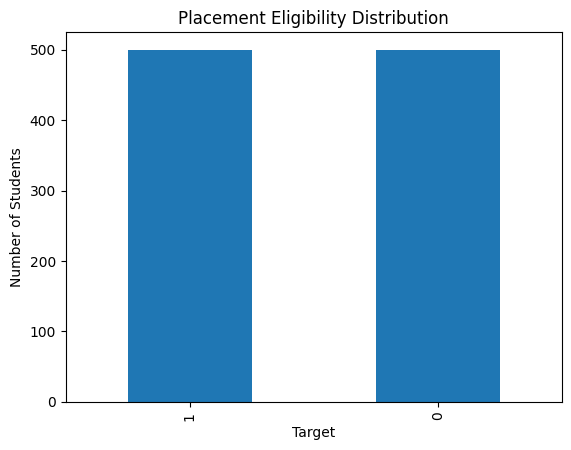

In [3]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.title("Placement Eligibility Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Students")
plt.show()

## 4. Data Preprocessing

In [4]:
X = df.drop('target', axis=1)
y = df['target']

## 5. Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6. Logistic Regression Model

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 7. Model Prediction

In [7]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0
 1 0 1 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0
 1 1 0 1 1 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0
 0 1 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 1 1
 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1
 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0]


## 8. Model Evaluation

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7
Precision: 0.6886792452830188
Recall: 0.73
F1 Score: 0.7087378640776699
ROC-AUC: 0.7873
Confusion Matrix:
[[67 33]
 [27 73]]


## 9. Confusion Matrix

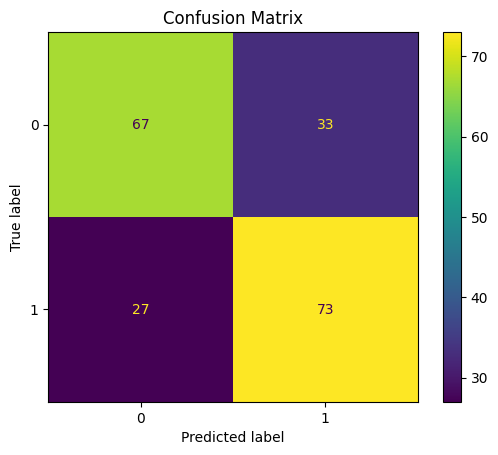

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

## 10. Feature Coefficient Analysis

In [10]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))

              Feature  Coefficient
5            backlogs     0.368014
3  projects_completed     0.318701
1      attendance_pct     0.028213
4   internship_months    -0.023373
2        coding_score    -0.303601
0                cgpa    -0.371978


## 11. Conclusion

The Logistic Regression model was developed to predict student placement eligibility based on academic and placement-related features. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC and confusion matrix.

The results help understand how the selected features contribute to placement eligibility prediction.